# Image Classification using Deep Learning on CIFAR-10 with Model Comparison

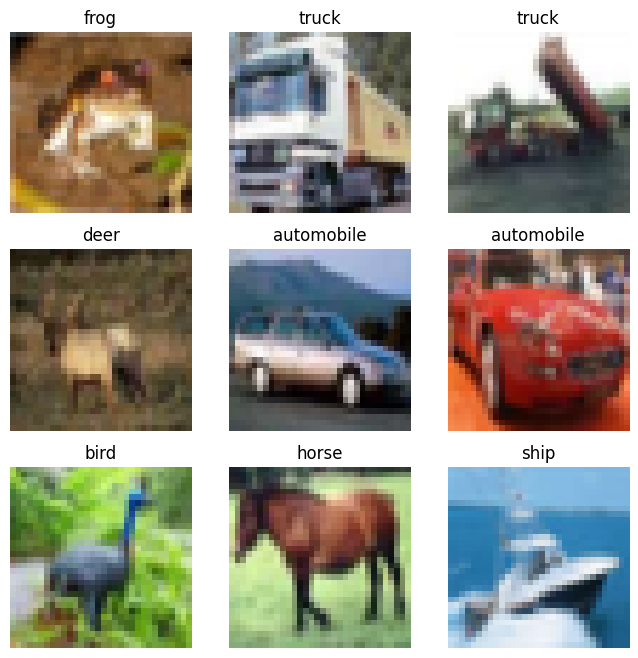

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.4371 - loss: 1.5406 - val_accuracy: 0.5523 - val_loss: 1.2418
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5892 - loss: 1.1607 - val_accuracy: 0.6236 - val_loss: 1.0671
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6471 - loss: 1.0013 - val_accuracy: 0.6563 - val_loss: 0.9751
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6801 - loss: 0.9081 - val_accuracy: 0.6789 - val_loss: 0.9229
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7048 - loss: 0.8395 - val_accuracy: 0.6891 - val_loss: 0.9201
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7261 - loss: 0.7846 - val_accuracy: 0.6922 - val_loss: 0.8983
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7438 - loss: 0.7342 - val_accuracy: 0.6991 - val_loss: 0.8631
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7577 - 

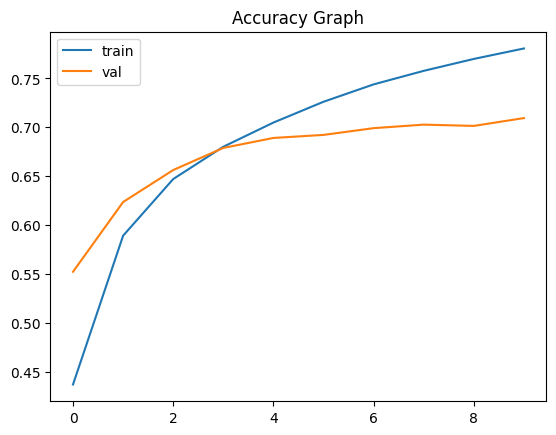

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models
import warnings
warnings.filterwarnings("ignore")
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
# Normalize
X_train, X_test = X_train / 255.0, X_test / 255.0
#Visualize Data
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()
#Build CNN Model
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
#Model Compilation
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#Train the model
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_test, y_test))
#Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)
#Accuracy Graph
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy Graph")
plt.show()